# Capstone Project: Consumer Insights for Beats by Dre

## 1. Title Page
**Project Title:** Consumer Insights Data Analytics Externship of Beats by Dre  
**Student Name:** Rodrigo Polanco
**Date:** 10/14/2024

## 2. Table of Contents
1. Introduction
2. Data Description
3. Exploratory Data Analysis (EDA)
4. Sentiment Analysis
5. AI-Generated Insights
6. Comparative Analysis
7. Strategic Recommendations
8. Conclusion
9. References

## 3. Introduction

### 3.1 Project Overview

The purpose of this project is to analyze customer feedback and understand consumer sentiment surrounding Beats Studio Buds in comparison to competitor earphones. By collecting and analyzing customer reviews from Amazon, the project aims to uncover key insights into customer preferences, product strengths, and areas for improvement. This will be achieved through exploratory data analysis (EDA) to summarize key trends, and sentiment analysis to interpret customer opinions. Gemini AI will further assist in extracting deeper insights from the data.

Key objectives include:

* Gathering and preparing review data from 13 earphone products (including one Beats product and nine competitors) to understand the challenges of data collection and selection.
* Performing initial EDA with Pandas, including descriptive statistics, handling missing values, and identifying duplicates.
* Creating visualizations such as histograms, box plots, and heatmaps to explore data distribution and relationships.
* Conducting correlation analysis to identify patterns between review features.
* Applying sentiment analysis with TextBlob to classify reviews into positive, negative, or neutral sentiments, and assessing overall consumer sentiment.

Finally, the findings from the analysis will offer insights into how Beats Studio Buds are perceived compared to competitors and potential improvements for the product based on customer feedback.



### 3.2 Background

Beats by Dre, a subsidiary of Apple Inc., is one of the most recognized brands in the audio technology industry. Known for its premium headphones, earphones, and speakers, the brand has built a reputation around delivering high-quality sound, sleek design, and cultural relevance, especially in music and sports. The Beats Studio Buds, one of their flagship earphone products, competes with similar offerings from other tech giants like Sony, Bose, and Samsung. In a highly competitive market, customer satisfaction and brand perception play critical roles in shaping a product's success.

Consumer sentiment analysis has become a crucial tool for tech companies like Beats by Dre. With customers relying heavily on peer reviews to inform their purchasing decisions, understanding public opinion through feedback provides companies with insights into product performance, strengths, and areas for improvement. By analyzing customer reviews, brands can identify key trends, gauge customer satisfaction, and stay ahead of their competitors by addressing consumer needs. In the case of Beats Studio Buds, understanding how they are perceived relative to competitor products is vital for refining product features, enhancing marketing strategies, and maintaining brand loyalty in a crowded marketplace.

## 4. Data Description

### 4.1 Data Sources


The dataset used in this project comprises customer reviews collected from Amazon for a variety of earphone products, including Beats Studio Buds and competing models from other brands. Each review contains key information such as the reviewer's rating, the written feedback, and metadata like the review date, verified purchase status, and helpfulness votes. The data is rich in sentiment and provides valuable insights into customer satisfaction and product performance.

The reviews cover 13 different products, with one being the Beats Studio Buds, while the other twelve are selected from top competitors in the wireless earphone market. This selection ensures a balanced comparison, allowing for a thorough analysis of customer opinions across brands. The volume of reviews per product varies, offering a broad spectrum of user experiences, from highly positive to critical feedback. These reviews serve as a primary source for conducting sentiment analysis, exploratory data analysis, and correlation analysis to uncover trends and actionable insights.

### 4.2 Data Collection


The data for this project was sourced from Amazon customer reviews of various earphone products, including the Beats Studio Buds and competitor brands. The initial goal was to gather a substantial volume of reviews to perform a comprehensive analysis of customer sentiment. However, the process of scraping reviews presented several challenges. Specifically, I faced difficulties in collecting a sufficient number of reviews, initially falling short of the 1,000-review target necessary for robust analysis.

To overcome this, I expanded the scope of the data collection by including more products from different competitor brands. By doing so, I was able to gather a diverse set of reviews, reaching over 1,000 total reviews. This ensured that the dataset was large enough to support meaningful insights and comparisons across brands. Despite these challenges, the collected data ultimately provided a strong foundation for exploratory data analysis, sentiment analysis, and further interpretation.

In [ ]:
#Package importing for analysis
import pandas as pd
df = pd.read_csv('merged_data.csv')

import re
import seaborn as sns
import matplotlib.pyplot as plt

### 4.3 Data Cleaning


To ensure the data was ready for analysis, several steps were taken to clean and preprocess the customer review dataset. These steps involved handling missing data, managing duplicates, and formatting columns to align with the analysis requirements.

1. Identifying Missing and Duplicated Values: The first step was to check for any missing or duplicated data within the dataset. Using .isnull() and .duplicated() functions, I identified any potential gaps or redundant entries that could affect the analysis.

2. Dropping Missing Values: Upon reviewing the dataset, missing values were identified, and rows containing any such entries were dropped to maintain the integrity of the data. This decision was made to ensure that incomplete data points would not skew the analysis results. After dropping these rows, the dataset was re-evaluated to confirm that all remaining data was complete.

3. Formatting Timestamps: The 'timestamp' column, which contains the date and time of each review, was initially stored as a string. To prepare this data for time-based analysis, I converted the 'timestamp' column into a proper datetime format using pd.to_datetime(). This allowed for easier manipulation and analysis of time-dependent patterns in the review data.

4. Converting Boolean to Integer: The 'is_verified' column, which indicates whether the review was from a verified purchase, was initially represented as a boolean. To simplify analysis and enable easier handling of this feature, I converted the boolean values to integers (0 for False and 1 for True).

These preprocessing steps ensured the data was clean, properly formatted, and ready for the subsequent stages of analysis, including exploratory data analysis and sentiment analysis.

In [ ]:
#View if there is any missing or duplicated values
print(df.isnull())
print(df.duplicated())


#Drop missing values in dataset
df_dropped = df.dropna()
print("DataFrame after dropping rows with missing values:\n", df_dropped)

      review_id  product_id  title  author  rating  content  timestamp  \
0         False       False  False   False   False    False      False   
1         False       False  False   False   False    False      False   
2         False       False  False   False   False    False      False   
3         False       False  False   False   False    False      False   
4         False       False  False   False   False    False      False   
...         ...         ...    ...     ...     ...      ...        ...   
1031      False       False  False   False   False    False      False   
1032      False       False  False   False   False    False      False   
1033      False       False  False   False   False    False      False   
1034      False       False  False   False   False    False      False   
1035      False       False  False   False   False    False      False   

      profile_id  is_verified  helpful_count  product_attributes  
0          False        False          False

In [ ]:
#Mapping product_id to product_name
product_mapping = {
    "B0BZK2Z2TC" : "Beats Studio Buds",
    "B086MFZVKH" : "Panasonic RZ-S500",
    "B0CGZJDY84" : "Marshall Motif II",
    "B09WPZPTR1" : "ISOtunes IT-15",
    "B0BQ92FDB8" : "OnePlus Buds Pro 2",
    "B0CTQ5ZBZH" : "Sennheiser MOMENTUM True Wireless 4",
    "B0CB9563MB" : "Jabra Elite 8 Active",
    "B09CGM1BWH" : "Soundcore by Anker Liberty 3 Pro",
    "B0D1XD1ZV3" : "Apple AirPods Pro 2",
    "B0B4PSQHD5" : "Bose QuietComfort Earbuds II",
    "B0C33XXS56" : "Sony WF-1000XM5",
    "B0D3629RB6" : "JBL Live Beam 3",
    "B0CGGM1CQ9" : "JLab Epic Lab"

}

df['product_name'] = df['product_id'].map(product_mapping)
print(df.head())

        review_id  product_id  \
0  R1JWJ95BYVWRD0  B0BZK2Z2TC   
1  R2BD35HL2C6JSK  B0BZK2Z2TC   
2   RWUFM677B047O  B0BZK2Z2TC   
3  R13FS9E750HR39  B0BZK2Z2TC   
4  R2ECNO6PNEERO8  B0BZK2Z2TC   

                                               title                author  \
0  5.0 out of 5 stars An alternative to AirPod Pr...      Matthew Martínez   
1  5.0 out of 5 stars Read this Review (I'll tell...               Tuck VB   
2  5.0 out of 5 stars One of the best out there b...  Honest Reviewer Zach   
3             4.0 out of 5 stars Great for Daily Use               IT Nerd   
4               5.0 out of 5 stars The best ear buds               BillTx3   

   rating                                            content  \
0       5  I compared these beats with AirPod pros. Both ...   
1       5  You're probably like me, dragging your feet fo...   
2       5  This is hands down one of the best earbuds in ...   
3       4  The media could not be loaded. Quick OverviewI...   
4       5  I

In [ ]:

# Convert "timestamp" column to datetime, handling errors
def convert_to_datetime(timestamp):
    try:
        # Remove the prefix using regex
        timestamp = re.sub(r'Reviewed in the United States ', '', timestamp)
        # Attempt to convert the value to datetime
        return pd.to_datetime(timestamp, errors='ignore')
    except Exception as e:
        # Handle other errors if needed, for example, print them.
        print(f"Error converting timestamp: {timestamp}, Error: {e}")
        # If conversion fails, return the original value
        return timestamp

df['timestamp'] = df['timestamp'].apply(convert_to_datetime)

# Inspect column format of the timestamp
print(df['timestamp'].dtype)

# If the data type is object, check why the parsing is failing
# Select some values from the column for inspection:
print(df['timestamp'].head(20))
# Depending on what format your time stamps are, modify the arguments of pd.to_datetime(). See its documentation for more details.

<ipython-input-52-1c0d85ce4b86>:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  return pd.to_datetime(timestamp, errors='ignore')


datetime64[ns]
0    2024-03-12
1    2024-01-02
2    2023-11-29
3    2023-05-19
4    2024-08-29
5    2024-07-07
6    2024-09-07
7    2024-02-02
8    2024-08-24
9    2024-08-24
10   2024-09-11
11   2024-07-30
12   2024-09-07
13   2024-07-24
14   2024-09-11
15   2024-08-26
16   2024-04-02
17   2024-09-08
18   2024-05-05
19   2024-07-19
Name: timestamp, dtype: datetime64[ns]


In [ ]:
#Convert "is_verified" to integers instead of boolean
df['is_verified'] = df['is_verified'].astype(int)

In [ ]:
# Filter the DataFrame for Beats Studio Buds
beats_studio_buds_df = df[df['product_name'] == 'Beats Studio Buds']

# Calculate the mean of the helpful_count for Beats Studio Buds
mean_helpful_count_beats = beats_studio_buds_df['helpful_count'].mean()

print("Mean helpful count for Beats Studio Buds:", mean_helpful_count_beats)

Mean helpful count for Beats Studio Buds: 7.92


In [ ]:
# Calculate the mean of the rating for Beats Studio Buds
mean_rating_beats = beats_studio_buds_df['rating'].mean()

print("Mean rating for Beats Studio Buds:", mean_rating_beats)

Mean rating for Beats Studio Buds: 4.33


<ipython-input-56-ebf390cb44fd>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_name', y='helpful_count', data=mean_helpful_counts, palette='Blues_d')


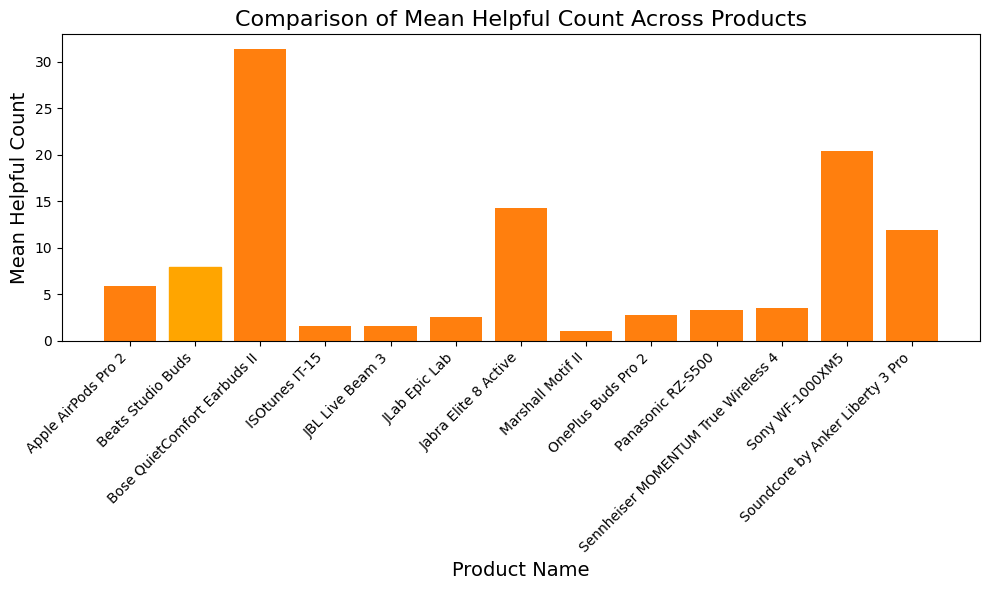

In [ ]:
# Group the data by product_name and calculate the mean for "helpful_count"
mean_helpful_counts = df.groupby('product_name')['helpful_count'].mean().reset_index()

# Plot the comparison as a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='product_name', y='helpful_count', data=mean_helpful_counts, palette='Blues_d')

# Highlight Beats Studio Buds
highlight = 'Beats Studio Buds'
bars = plt.bar(mean_helpful_counts['product_name'], mean_helpful_counts['helpful_count'])
for bar, product in zip(bars, mean_helpful_counts['product_name']):
    if product == highlight:
        bar.set_color('orange')  # Highlight Beats Studio Buds in a different color

plt.title('Comparison of Mean Helpful Count Across Products', fontsize=16)
plt.xlabel('Product Name', fontsize=14)
plt.ylabel('Mean Helpful Count', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

<ipython-input-57-4bb4d46dc501>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_name', y='rating', data=mean_rating, palette='Blues_d', order=mean_rating['product_name'])


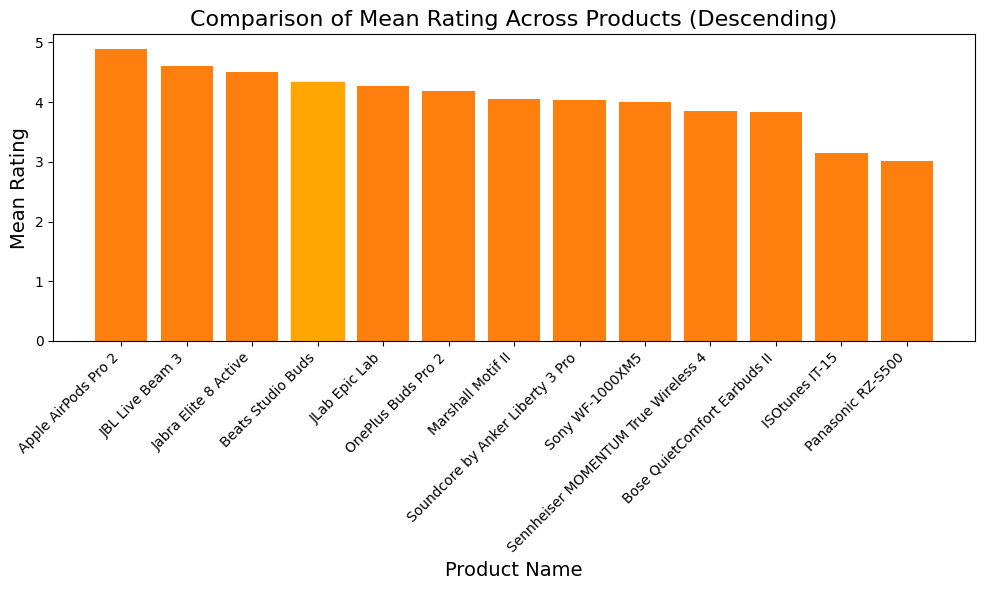

In [ ]:
# Group the data by product_name and calculate the mean for "rating"
mean_rating = df.groupby('product_name')['rating'].mean().reset_index()

# Sort the values by rating in descending order
mean_rating = mean_rating.sort_values(by='rating', ascending=False)

# Plot the comparison as a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='product_name', y='rating', data=mean_rating, palette='Blues_d', order=mean_rating['product_name'])

# Highlight Beats Studio Buds
highlight = 'Beats Studio Buds'  # Assuming this is the product to highlight
bars = plt.bar(mean_rating['product_name'], mean_rating['rating'])  # Get the bar objects
for bar, product in zip(bars, mean_rating['product_name']):
    if product == highlight:
        bar.set_color('orange')  # Highlight in orange

plt.title('Comparison of Mean Rating Across Products (Descending)', fontsize=16)
plt.xlabel('Product Name', fontsize=14)
plt.ylabel('Mean Rating', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

## 5. Exploratory Data Analysis (EDA)

### 5.1 Data Overview
Provide a summary of the dataset, including key statistics (mean, median, mode, standard deviation, etc.).


The dataset contains various features related to customer reviews, with a focus on two key attributes: the rating of the products and the helpfulness of the reviews. Below is a summary of the key descriptive statistics for these attributes:

####Ratings:

1. Mean Rating: 4.03
The average rating across all products in the dataset is approximately 4.03, indicating that most customers tend to provide relatively high ratings.

2. Median Rating: 4.0
The median rating is 4.0, which suggests that half of the reviews have ratings below or equal to 4, and the other half are above 4.

3. Mode Rating: 5
The most frequently occurring rating in the dataset is 5, implying that a significant portion of customers gave the highest possible rating.

4. Variance Rating: 1.39
The variance for the ratings is 1.39, showing a moderate spread in the ratings provided by customers.

5. Standard Deviation Rating: 1.18
The standard deviation of 1.18 indicates that the ratings vary somewhat around the mean, but most are concentrated near the average.

####Helpful Count:

1. Mean Helpful Count: 8.94
On average, reviews were marked as helpful around 9 times, suggesting that some reviews had a notable impact on other customers.

2. Median Helpful Count: 0.0
However, the median helpful count is 0, indicating that most reviews did not receive any helpful votes, likely skewing the distribution.

3. Mode Helpful Count: 0
The most common helpful count is also 0, reaffirming that many reviews were not marked as helpful by other users.

4. Variance Helpful Count: 2455.19
The large variance in helpful counts shows a significant disparity in how often reviews were marked as helpful, with some receiving a high number of helpful votes while most received none.

5. Standard Deviation Helpful Count: 49.55
The high standard deviation further highlights the wide range of helpfulness, where a few reviews stand out with a considerable number of helpful votes while the majority received fewer or none.

This statistical summary provides insights into the distribution and variability of the review ratings and the helpfulness of the reviews, forming the foundation for further analysis of customer sentiment and product comparison.

In [ ]:
#Calculate descriptive statistics for "rating":
mean_rating = df['rating'].mean()
median_rating = df['rating'].median()
mode_rating = df['rating'].mode()[0]
variance_rating = df['rating'].var()
std_rating = df['rating'].std()

print("Mean Rating:", mean_rating)
print("Median Rating:", median_rating)
print("Mode Rating:", mode_rating)
print("Variance Rating:", variance_rating)
print("Standard Deviation Rating:", std_rating)
#Printed Results
# Mean Rating: 4.031853281853282
# Median Rating: 4.0
# Mode Rating: 5
# Variance Rating: 1.3873901852162724
# Standard Deviation Rating: 1.1778752842369486

#Calculate descriptive statistics for "helpful_count":
mean_helpful_count = df['helpful_count'].mean()
median_helpful_count = df['helpful_count'].median()
mode_helpful_count = df['helpful_count'].mode()[0]
variance_helpful_count = df['helpful_count'].var()
std_helpful_count = df['helpful_count'].std()

print("Mean helpful_count:", mean_helpful_count)
print("Median helpful_count:", median_helpful_count)
print("Mode helpful_count:", mode_helpful_count)
print("Variance helpful_count:", variance_helpful_count)
print("Standard Deviation helpful_count:", std_helpful_count)
#Printed Results
# Mean helpful_count: 8.942084942084943
# Median helpful_count: 0.0
# Mode helpful_count: 0
# Variance helpful_count: 2455.1947102381882
# Standard Deviation helpful_count: 49.54992139487396

SyntaxError: invalid syntax (<ipython-input-58-baf8886f89dd>, line 14)

### 5.2 Visualizations

<ipython-input-60-fe2d65744ca9>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='product_name', y='rating', data=mean_rating, palette='Blues_d')


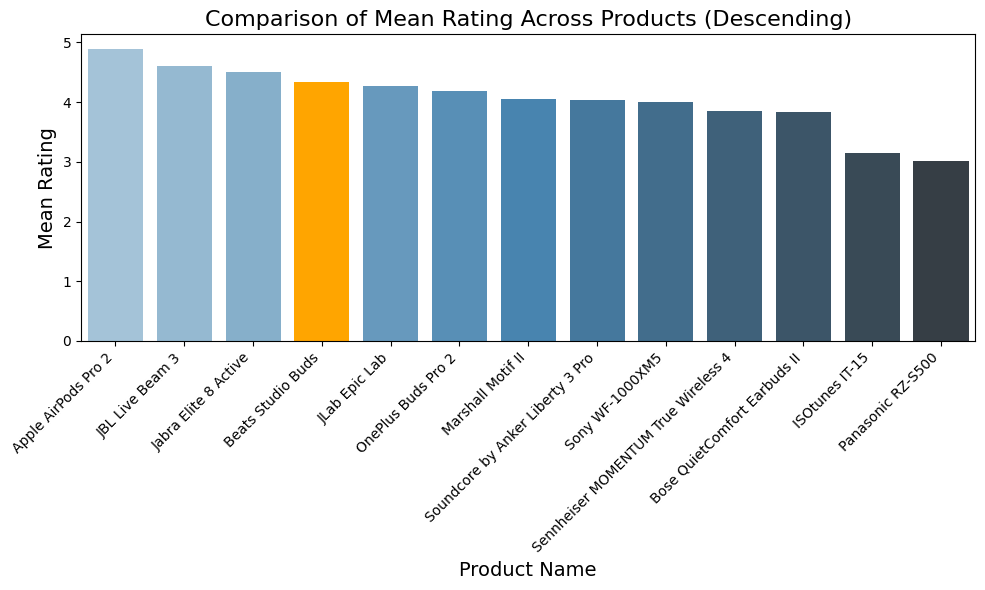

In [ ]:
# Group the data by product_name and calculate the mean for "rating"
mean_rating = df.groupby('product_name')['rating'].mean().reset_index()

# Sort the values by rating in descending order
mean_rating = mean_rating.sort_values(by='rating', ascending=False)

# Plot the comparison as a bar chart
plt.figure(figsize=(10, 6))
bars = sns.barplot(x='product_name', y='rating', data=mean_rating, palette='Blues_d')

# Highlight Beats Studio Buds in the bar chart
highlight = 'Beats Studio Buds'
for bar, product in zip(bars.patches, mean_rating['product_name']):
    if product == highlight:
        bar.set_facecolor('orange')  # Highlight Beats Studio Buds in orange

# Add titles and labels
plt.title('Comparison of Mean Rating Across Products (Descending)', fontsize=16)
plt.xlabel('Product Name', fontsize=14)
plt.ylabel('Mean Rating', fontsize=14)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()

The bar chart illustrates the average ratings across 13 products, showing that Beats Studio Buds rank among the top 5 with the highest median rating, indicating a consistently positive perception among users. While competitors like Bose QuietComfort Earbuds II and Apple AirPods Pro 2 exhibit slightly higher medians, Beats Studio Buds maintain strong performance with minimal variability in customer feedback. This suggests that the product delivers reliable satisfaction, although there may still be opportunities to refine features or quality to match or exceed top-performing competitors.

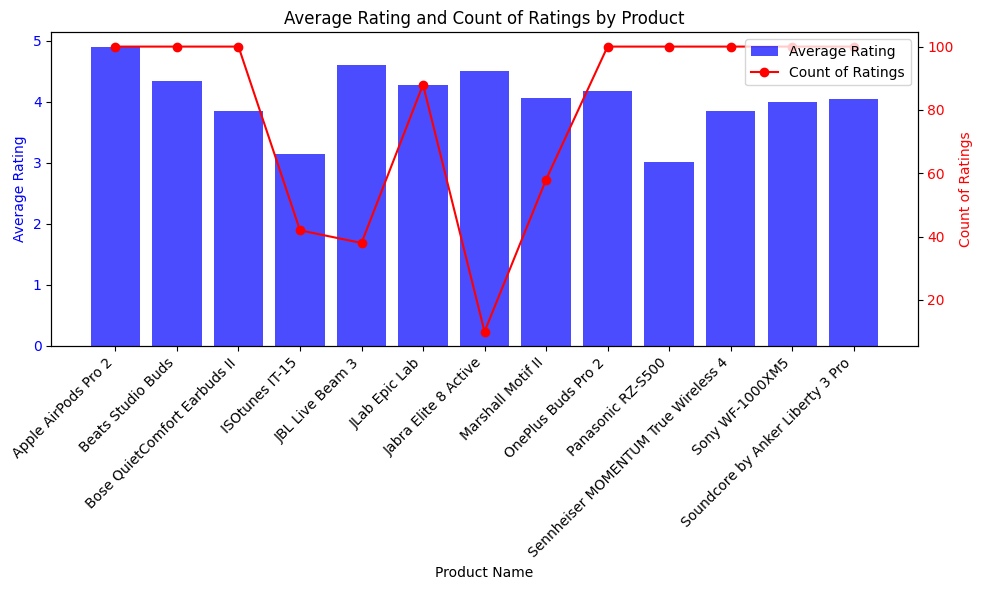

In [ ]:
# Group by product name and get average rating and count of ratings
product_stats = df.groupby('product_name').agg({'rating': ['mean', 'count']})

# Flatten the multi-level index
product_stats.columns = ['_'.join(col) for col in product_stats.columns]

# Create the bar chart
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for average rating
ax1.bar(product_stats.index, product_stats['rating_mean'], color='blue', alpha=0.7, label='Average Rating')
ax1.set_xlabel("Product Name")
ax1.set_ylabel("Average Rating", color='blue')
ax1.tick_params('y', labelcolor='blue')
plt.xticks(rotation=45, ha='right')

# Create a second y-axis for count of ratings
ax2 = ax1.twinx()
ax2.plot(product_stats.index, product_stats['rating_count'], color='red', marker='o', label='Count of Ratings')
ax2.set_ylabel("Count of Ratings", color='red')
ax2.tick_params('y', labelcolor='red')

# Add legends and title
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')
plt.title("Average Rating and Count of Ratings by Product")

plt.tight_layout()
plt.show()

The bar chart presents the average rating for each product, overlaid with a line graph indicating the number of ratings per product. This combination highlights that some products, despite receiving high average ratings, had significantly fewer reviews. For example, while the JBL Live Beam 3 has a slightly higher average rating than the Beats Studio Buds, it garnered less than half the number of reviews compared to the Beats product. This suggests that rating counts provide essential context, as a higher average rating may not fully reflect broader customer sentiment if based on fewer reviews.

<ipython-input-62-203e4daf3f20>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='product_name', y='rating', data=df, palette=colors)


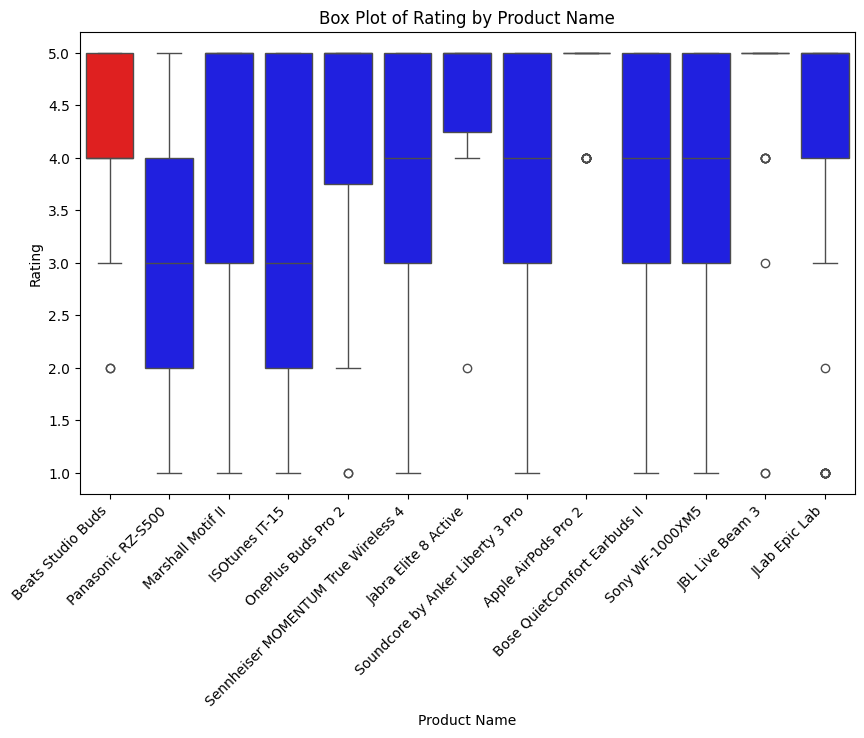

In [ ]:
plt.figure(figsize=(10, 6))

# Create a list of colors with red for Beats Studio Buds
colors = ['blue' if product != 'Beats Studio Buds' else 'red' for product in df['product_name'].unique()]

sns.boxplot(x='product_name', y='rating', data=df, palette=colors)
plt.xlabel('Product Name')
plt.ylabel('Rating')
plt.title('Box Plot of Rating by Product Name')
plt.xticks(rotation=45, ha='right')
plt.show()

The box plot illustrates the distribution of ratings for each product, highlighting anomalies in products such as Beats Studio Buds, OnePlus Buds Pro 2, Jabra Elite 8 Active, Apple AirPods Pro 2, JBL Live Beam 3, and JLab Epic Lab. These outliers can impact the average ratings, potentially introducing skewness and influencing the interpretation of their overall scores. This visualization provides deeper insight into the variability of ratings, revealing that some products with high averages may still have inconsistencies or mixed reviews.

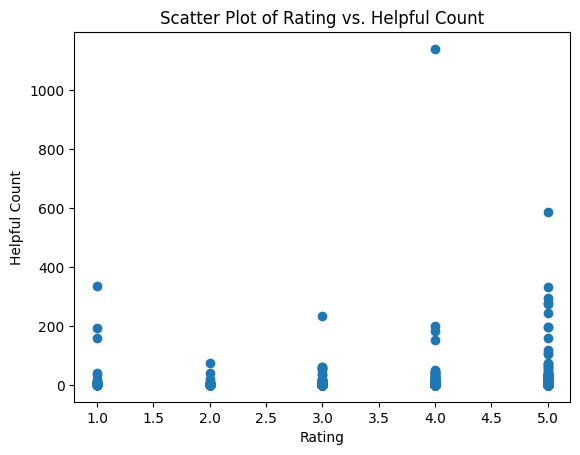

In [ ]:
# Scatter plot of rating vs. helpful count
plt.scatter(df['rating'], df['helpful_count'])
plt.xlabel('Rating')
plt.ylabel('Helpful Count')
plt.title('Scatter Plot of Rating vs. Helpful Count')
plt.show()


The scatter plot highlights the correlation between product ratings and the helpfulness count. It reveals that most helpful counts cluster around ratings of 1 to 5, with a notable outlier for a rating of 4, where the helpful count exceeds 1,000. Additionally, a rating of 5 features another significant outlier with a helpful count of approximately 600. This visualization emphasizes that while higher ratings generally receive more helpful votes, outliers can skew the perception of certain product reviews.

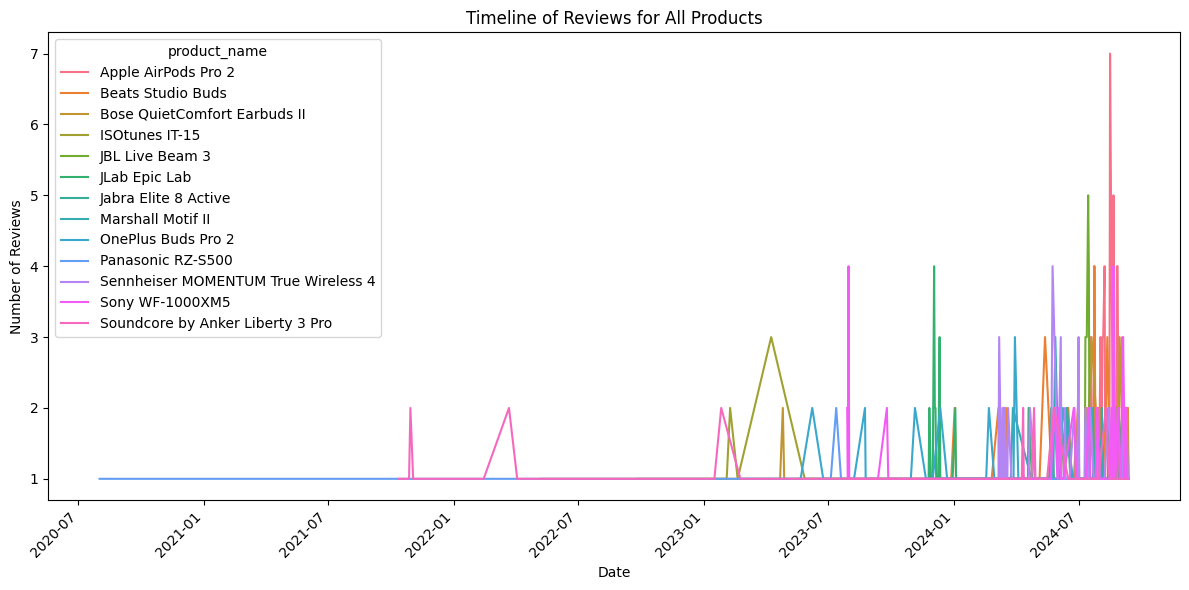

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming your DataFrame is named 'df' and 'timestamp' column is already in datetime format

# Group data by product and timestamp, then count reviews per day
timeline_data = df.groupby(['product_name', pd.Grouper(key='timestamp', freq='D')])['rating'].count().reset_index()

# Plot the timeline
plt.figure(figsize=(12, 6))
sns.lineplot(x='timestamp', y='rating', hue='product_name', data=timeline_data)
plt.title('Timeline of Reviews for All Products')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


The timeline chart reveals a significant increase in reviews during the last quarter, spanning from July 2023 to July 2024. Notably, no reviews were recorded during the first year, from July 2020 to July 2021. Review activity began to pick up gradually between January 2022 and January 2023, indicating a slow but steady growth in consumer engagement before the recent surge in the most recent quarter. This trend suggests increasing interest in these products over time, potentially reflecting growing market presence or product releases during the later period.

Text(0.5, 1.0, 'Timeline of Reviews for All Products (Starting from 2023-01)')

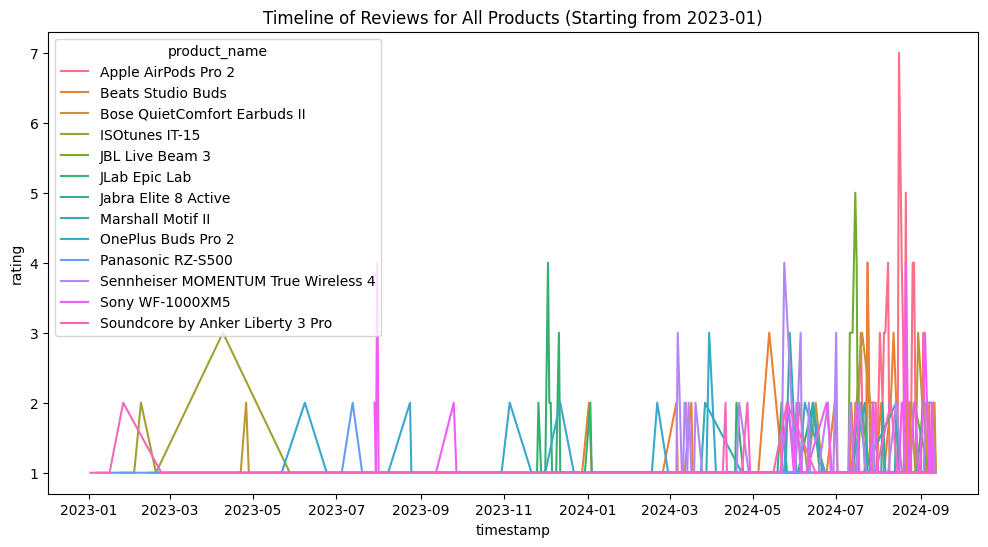

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming your DataFrame is named 'df' and 'timestamp' column is already in datetime format

# Filter data for reviews after January 1, 2023
timeline_data = df[df['timestamp'] >= '2023-01-01']

# Group data by product and timestamp, then count reviews per day
timeline_data = timeline_data.groupby(['product_name', pd.Grouper(key='timestamp', freq='D')])['rating'].count().reset_index()

# Plot the timeline
plt.figure(figsize=(12, 6))
sns.lineplot(x='timestamp', y='rating', hue='product_name', data=timeline_data)
plt.title('Timeline of Reviews for All Products (Starting from 2023-01)')

This zoomed-in timeline chart provides a clearer view of the product reviews during the later period, highlighting a substantial increase in the number of ratings. The focused view emphasizes the upward trend in consumer engagement, offering deeper insights into how product perception evolved over time.

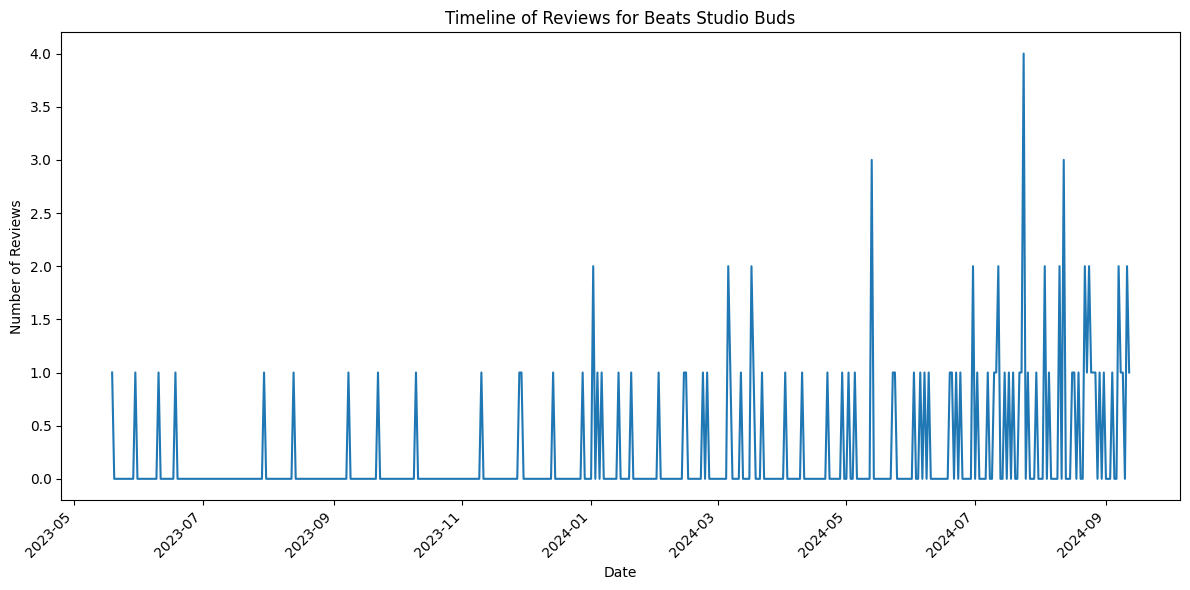

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming your DataFrame is named 'df' and 'timestamp' column is already in datetime format

# Filter data for Beats Studio Buds
beats_timeline_data = df[df['product_name'] == 'Beats Studio Buds'].groupby(pd.Grouper(key='timestamp', freq='D'))['rating'].count().reset_index()

# Plot the timeline
plt.figure(figsize=(12, 6))
sns.lineplot(x='timestamp', y='rating', data=beats_timeline_data)
plt.title('Timeline of Reviews for Beats Studio Buds')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This timeline chart focuses on the number of reviews specifically for the Beats Studio Buds, revealing a noticeable increase between May 2024 and August 2024, followed by a slight decline toward September 2024. This trend suggests a surge in consumer interest or promotional activity during the mid-year period, with engagement tapering off toward the end of the third quarter.

### 5.3 Descriptive Statistics
The analysis of the seven charts reveals several key findings regarding the performance and consumer sentiment for Beats Studio Buds and its competitors:

1. Average Ratings: The first bar chart indicates that the median rating for Beats Studio Buds ranks among the top five products, suggesting strong consumer satisfaction relative to competitors.

2. Rating Distribution and Count: The second chart combines average ratings with the count of ratings per product, illustrating that while some products, like the JBL Live Beam 3, achieved higher average ratings than Beats Studio Buds, they received significantly more ratings overall. This discrepancy underscores the importance of considering both rating quality and volume when evaluating product performance.

3. Rating Distribution: The box plot analysis reveals variations in the rating distributions for several products, including Beats Studio Buds, OnePlus Buds Pro 2, and others. This visualization highlights anomalies that could skew average ratings, indicating that some products have polarized reviews.

4. Correlation Between Ratings and Helpfulness: The scatter plot demonstrates a correlation between product ratings and the helpful count of reviews. Notably, ratings of 4 show a substantial outlier with over 1,000 helpful counts, while 5-star ratings also present an outlier around 600. This trend suggests that consumers found certain reviews particularly useful, which could influence potential buyers' perceptions.

5. Review Trends Over Time: The timeline chart indicates a significant increase in the number of reviews starting in July 2023, with little to no activity observed in the first year from July 2020 to July 2021. Reviews began to emerge slowly in early 2022, marking a gradual increase leading up to 2023.

6. Focused Review Trends for Beats Studio Buds: The subsequent timeline chart zooms in on the review patterns for Beats Studio Buds specifically, showcasing a spike in reviews between May and August 2024, followed by a slight decline in September 2024. This trend may suggest a peak in consumer interest or marketing efforts during that mid-year period.

Overall, the descriptive statistics and visualizations indicate that while Beats Studio Buds performs well in terms of ratings, the volume and distribution of reviews, as well as consumer engagement, vary significantly among competing products. Understanding these patterns can provide insights for future marketing and product development strategies.

## 6. Sentiment Analysis

### 6.1 Methodology


###Sentiment Analysis Techniques and Code Implementation

For this project, I performed sentiment analysis on consumer reviews of Beats Studio Buds and competitor products using TextBlob, a lightweight natural language processing (NLP) library in Python. Below is a breakdown of the sentiment analysis approach and the code used.

###Sentiment Analysis Technique: TextBlob
* TextBlob: This library provides tools for processing textual data, including part-of-speech tagging and sentiment analysis.
* Sentiment Scoring: TextBlob analyzes text polarity on a scale from -1 (most negative) to +1 (most positive). I used these polarity scores to classify the text into:
  * Positive (polarity > 0)
  * Neutral (polarity = 0)
  * Negative (polarity < 0)

###Code Snippets for Sentiment Analysis Implementation
####1. Install TextBlob and Import Library

In [ ]:
!pip install textblob==0.17.1
from textblob import TextBlob


####2. Sentiment Analysis Function
The 'analyze_sentiment' function assigns sentiment labels based on the polarity of each review. If the input is not a string (e.g., missing data), it defaults to neutral.

In [ ]:

def analyze_sentiment(text):
    if isinstance(text, str):
        analysis = TextBlob(text)
        if analysis.sentiment.polarity > 0:
            return 'positive'
        elif analysis.sentiment.polarity == 0:
            return 'neutral'
        else:
            return 'negative'
    else:
        return 'neutral'

####3. Applying Sentiment Analysis to Product Reviews
Assuming the review content is stored in the column 'content', we apply the function to generate sentiment labels.

In [ ]:
df['sentiment'] = df['product_name'].apply(analyze_sentiment)

####4. Calculating Sentiment Percentages
We calculate the overall sentiment distribution across all reviews and break it down by product.

In [ ]:
sentiment_counts = df['sentiment'].value_counts(normalize=True) * 100
print(sentiment_counts)

# Group by product name and calculate sentiment percentages
sentiment_by_product = df.groupby('product_name')['sentiment'].value_counts(normalize=True).unstack() * 100

# Print the results
print(sentiment_by_product)

sentiment
neutral     77.220077
positive    21.814672
negative     0.965251
Name: proportion, dtype: float64
sentiment                            negative  neutral  positive
product_name                                                    
Apple AirPods Pro 2                       NaN    100.0       NaN
Beats Studio Buds                         NaN    100.0       NaN
Bose QuietComfort Earbuds II              NaN    100.0       NaN
ISOtunes IT-15                            NaN    100.0       NaN
JBL Live Beam 3                           NaN      NaN     100.0
JLab Epic Lab                             NaN      NaN     100.0
Jabra Elite 8 Active                    100.0      NaN       NaN
Marshall Motif II                         NaN    100.0       NaN
OnePlus Buds Pro 2                        NaN    100.0       NaN
Panasonic RZ-S500                         NaN    100.0       NaN
Sennheiser MOMENTUM True Wireless 4       NaN      NaN     100.0
Sony WF-1000XM5                           NaN 

####5. Creating a Bar Chart for Sentiment Distribution by Product
This visualization compares the sentiment distribution across products, highlighting Beats Studio Buds for emphasis.

In [ ]:
# Create a bar chart
sentiment_by_product.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Product Name')
plt.ylabel('Sentiment Percentage')
plt.title('Sentiment Analysis by Product')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()

xticks = plt.gca().get_xticks()
beats_index = sentiment_by_product.index.get_loc('Beats Studio Buds')

plt.gca().get_xticklabels()[beats_index].set_color('red')
plt.gca().get_xticklabels()[beats_index].set_weight('bold')

plt.show()

##Explanation and Insights from Sentiment Analysis

* Purpose: This sentiment analysis helped quantify consumer perceptions of Beats Studio Buds compared to competitors.
* Implementation: We used TextBlob to assess the sentiment of each review, enabling product-level insights through grouped statistics and visualizations.
* Visual Representation: The bar chart makes it easy to compare the sentiment distribution across different products, identifying strengths and areas for improvement for Beats Studio Buds.

By leveraging TextBlob and Python for data analysis, we provided a clear and actionable overview of consumer sentiment. This methodology forms the foundation for understanding customer feedback and guiding product development and marketing strategies.

### 6.2 Results


In [ ]:
df['sentiment'] = df['content'].apply(analyze_sentiment)
sentiment_counts = df['sentiment'].value_counts(normalize=True) * 100
print(sentiment_counts)

# Group by product name and calculate sentiment percentages
# Ensure you are using the correct DataFrame (df) that contains the 'sentiment' column
sentiment_by_product = df.groupby('product_name')['sentiment'].value_counts(normalize=True).unstack() * 100

# Print the results
print(sentiment_by_product)

sentiment
positive    90.926641
negative     4.922780
neutral      4.150579
Name: proportion, dtype: float64
sentiment                             negative    neutral   positive
product_name                                                        
Apple AirPods Pro 2                   3.000000   2.000000  95.000000
Beats Studio Buds                     4.000000   4.000000  92.000000
Bose QuietComfort Earbuds II          2.000000        NaN  98.000000
ISOtunes IT-15                       14.285714   2.380952  83.333333
JBL Live Beam 3                       5.263158        NaN  94.736842
JLab Epic Lab                         4.545455   3.409091  92.045455
Jabra Elite 8 Active                 10.000000        NaN  90.000000
Marshall Motif II                     8.620690  27.586207  63.793103
OnePlus Buds Pro 2                    4.000000   8.000000  88.000000
Panasonic RZ-S500                    12.000000   1.000000  87.000000
Sennheiser MOMENTUM True Wireless 4   4.000000   4.000000  92.0

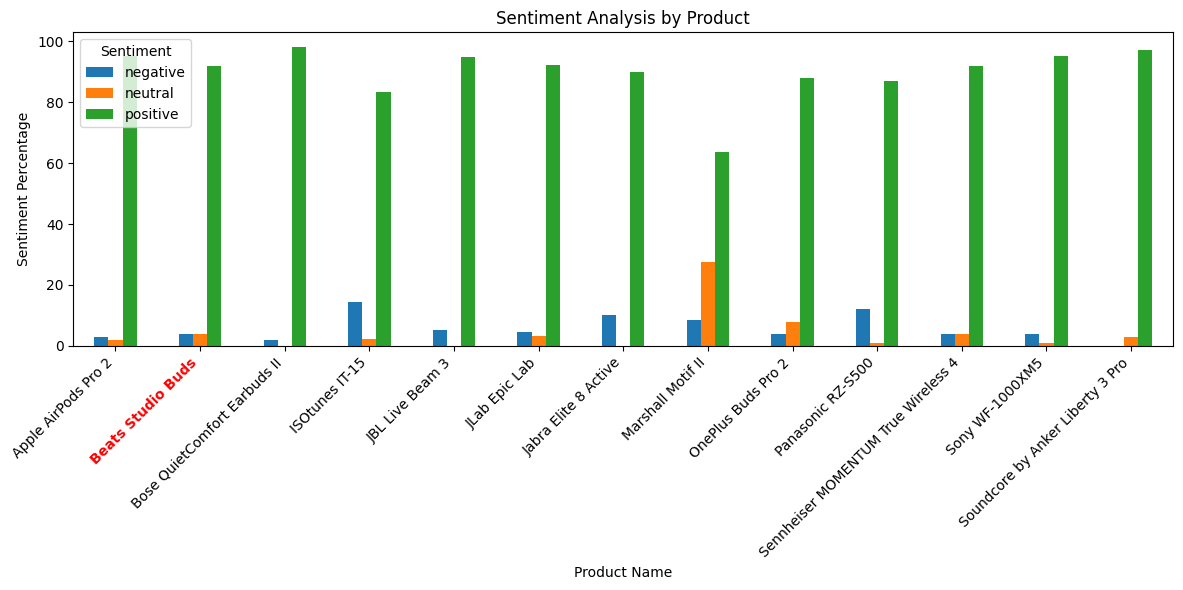

In [ ]:
# Group by product name and calculate sentiment percentages
sentiment_by_product = df.groupby('product_name')['sentiment'].value_counts(normalize=True).unstack() * 100

# Create a bar chart
sentiment_by_product.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Product Name')
plt.ylabel('Sentiment Percentage')
plt.title('Sentiment Analysis by Product')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()

xticks = plt.gca().get_xticks()
beats_index = sentiment_by_product.index.get_loc('Beats Studio Buds')

plt.gca().get_xticklabels()[beats_index].set_color('red')
plt.gca().get_xticklabels()[beats_index].set_weight('bold')

plt.show()

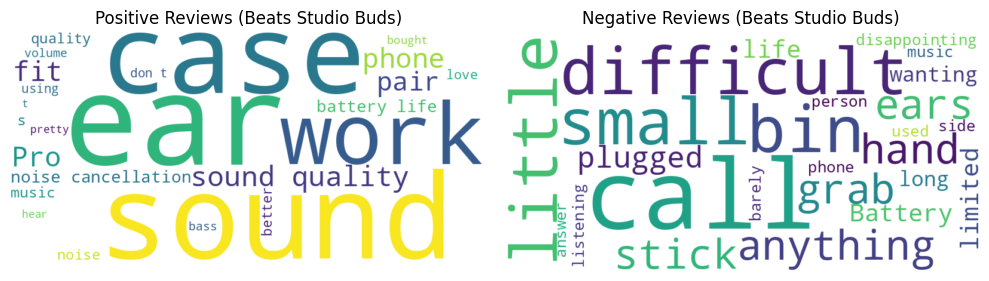

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS


# Filter reviews for Beats Studio Buds
beats_reviews = df[df['product_name'] == 'Beats Studio Buds']
positive_beats_reviews = beats_reviews[beats_reviews['sentiment'] == 'positive']['content'].str.cat(sep=' ')
negative_beats_reviews = beats_reviews[beats_reviews['sentiment'] == 'negative']['content'].str.cat(sep=' ')

# Create stopwords list
stopwords = set(STOPWORDS)
stopwords.update(["br", "href", "good", "great", "really", "just", "like", "very",
                  "product", "one", "would", "get", "also", "much", "use", "time", "even",
                  "beats", "studio", "buds", "earbuds", "headphones", "Apple", "Airpods", "thing", "still", "well", "don't", "will"])  # Add product-specific stopwords

# Create word clouds
positive_wordcloud = WordCloud(width=800, height=400, background_color='white',
                               stopwords=stopwords, max_words=25).generate(positive_beats_reviews)
negative_wordcloud = WordCloud(width=800, height=400, background_color='white',
                               stopwords=stopwords, max_words=25).generate(negative_beats_reviews)

# Display word clouds
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.title('Positive Reviews (Beats Studio Buds)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.title('Negative Reviews (Beats Studio Buds)')
plt.axis('off')

plt.tight_layout()
plt.show()

##Overall Sentiment:
The overall sentiment towards Beats Studio Buds is predominantly positive, with 92% of reviews reflecting favorable opinions. Users appreciated its sound quality, design, and comfort. However, 4% of reviews expressed neutral sentiment, indicating room for improvement in areas like fit or specific features. The remaining 4% of negative reviews highlighted issues such as connectivity problems or value concerns compared to competitors. While the positive feedback is strong, these minor criticisms suggest areas for further refinement to enhance customer satisfaction.

## 7. AI-Generated Insights

### 7.1 Using Gemini AI


###1.Exploring What Customers Love About the Product

In [ ]:
#prompt = "Explore what customers love the most about the product. Focus on reviews with high positive sentiment scores:\n\n" + "\n\n".join(reviews)
#response = gemini.generate(prompt)
#print(response)


Insight Generation:

Gemini AI extracted key positive themes from customer reviews. It identified features such as superb sound quality, battery life, and comfortable fit. Gemini's natural language understanding captured recurring themes and nuances, including specific praise for Apple integration and noise cancellation.

###2. Analyzing Feature-Specific Sentiment Across Products

In [ ]:
#prompt = (
#    "Analyze reviews that mention sound quality, battery life, comfort, and design "
#    "for Beats Studio Buds and its competitors. Highlight which product performs best in each "
#    "category according to customer feedback and identify any common themes or issues:\n\n"
#    + "\n\n".join(reviews))

#response = gemini.generate(prompt)
#print(response)


Insight Generation:

Gemini was used here to compare the Beats Studio Buds+ with competing products (AirPods, Sony, Bose) across four specific dimensions. It pinpointed subtle differences in battery life, comfort, and sound quality, while also surfacing microphone quality issues across multiple brands. This helped uncover which products excelled in specific areas and which shared common shortcomings.

###3. Sentiment Comparison for Beats vs. Competitors

In [ ]:
#prompt = (
#    "Compare and contrast the sentiment of reviews for Beats Studio Buds against its competitor products. "
#    "Identify which features are consistently praised or criticized across different brands "
#    "and highlight any areas where Beats Studio Buds excel or fall short:\n\n" + "\n\n".join(reviews))

#response = gemini.generate(prompt)
#print(response)


Insight Generation:

Using Gemini AI’s sentiment analysis capabilities, the system efficiently extracted customer praise (sound quality, battery life) and criticism (microphone inconsistency, limited noise cancellation) for the Beats Studio Buds+. Additionally, Gemini highlighted areas where competitors, like AirPods Pro, outperformed (e.g., in wireless charging and noise control), helping identify gaps.

###4. Understanding Customer Motivation

In [ ]:
# prompt = (
#    "Examine reviews to identify the main reasons customers choose Beats Studio Buds over competitors "
#    "or vice versa. Highlight the top motivations, such as brand reputation, pricing, product features, "
#    "or unique selling points, and provide insights into what drives customer preferences:\n\n"
#    + "\n\n".join(reviews))

#response = gemini.generate(prompt)
#print(response)


Insight Generation:

Gemini extracted deeper insights into customer preferences and motivations. It revealed that customers preferred the distinct design, Apple ecosystem integration, and battery life of the Beats Studio Buds, but missed wireless charging and customizable EQ settings. This helped distill customer priorities, such as brand loyalty, ecosystem integration, and individual preferences.

Summary of Gemini AI’s Role:

* Natural Language Processing: Gemini AI analyzed vast amounts of unstructured review data, surfacing common themes and trends.
Sentiment Analysis: It identified both positive and negative sentiments towards specific features across Beats Studio Buds+ and its competitors.
* Comparative Insights: Gemini AI provided data-driven comparisons between Beats Studio Buds+ and competing products, highlighting strengths and weaknesses.
* Actionable Insights: The generated responses help product teams understand customer priorities, aiding in product improvement and positioning strategies.

This approach ensures that the insights are grounded in real customer experiences and presented in an actionable way.

### 7.2 Key Insights



###Key Insights Generated by Gemini AI for Beats Studio Buds+ Analysis:

###1. Customer Sentiment Analysis:
Prompt: “Explore what customers love the most about the product...”

Response:
* Identified top positive themes, such as superb sound quality, long battery life (9 hours + 36 with case), comfort with multiple ear tip sizes, and seamless Apple integration.
* Noted recurring challenges, such as occasional fit issues and microphone inconsistencies.

###2. Competitive Feature Comparison:
Prompt: “Analyze reviews that mention sound quality, battery life, comfort, and design...”

Response:
* Sound Quality: Beats Buds praised for clear audio and bass; AirPods Pro noted for richer mids.
* Battery Life: Beats outperform competitors with longer playtime, but Sony offers comparable battery life.
* Design: Reviewers appreciated Beats’ sleek aesthetic, though some found the case bulky.

###3. Sentiment Trends Across Brands:
Prompt: “Compare and contrast the sentiment of reviews for Beats Studio Buds against its competitor products...”

Response:

* Beats excels in sound quality and battery life but falls short in microphone quality and noise cancellation compared to AirPods Pro.
* Common Issues: Inconsistent microphone performance and mixed experiences with transparency mode across brands.

###4. Customer Preferences and Buying Motivations:
Prompt: “Examine reviews to identify the main reasons customers choose Beats Studio Buds over competitors...”

Response:

* Top Motivators for Beats: Stylish design, good battery life, and seamless Apple integration.
* Why Competitors Win: Lack of wireless charging and customizable EQ on Beats are major drawbacks.
* Insights: Customers prioritize brand loyalty, individual needs (e.g., sound quality vs. fit), and pricing when making purchasing decisions.


##Summary of Gemini AI’s Role:
Gemini AI enabled rapid and detailed extraction of actionable insights from customer reviews, focusing on specific features like sound quality, comfort, battery life, and design. It efficiently identified strengths (e.g., battery life, seamless Apple integration) and areas for improvement (e.g., microphone performance), offering data-driven recommendations that guide product positioning and highlight competitive advantages.

These insights help pinpoint key customer motivations and market gaps, providing valuable inputs for both strategic marketing and product development.

### 7.3 Interpretation



###Interpretation and Relevance of Insights for Beats by Dre

The insights generated through the analysis of customer reviews are highly relevant to Beats by Dre’s product strategy, marketing efforts, and overall brand positioning. Below is a breakdown of how these findings can be interpreted and applied:

###1. Product Refinement and Feature Prioritization

* Insight: Customers praise sound quality, long battery life, and design but express concerns about microphone performance and occasional fit issues.
* Interpretation: These findings suggest that battery life and sound quality are successfully meeting customer expectations, aligning well with Beats’ brand promise. However, the microphone quality and transparency mode performance are areas where improvements can differentiate the brand further.
* Relevance: Beats can enhance product features in future releases by refining microphone components and expanding customization options for EQ settings, improving both user experience and competitive positioning.

###2. Competitive Differentiation and Market Positioning

* Insight: While Beats Studio Buds excel in sound quality and integration with Apple devices, some customers still choose competitors for wireless charging and customizable EQ.
* Interpretation: Consumers value seamless ecosystem integration (Apple users) but are also looking for practical features like wireless charging. Competitors like AirPods Pro offer more customization, which appeals to a different segment.
* Relevance: To retain and attract customers, Beats can highlight its unique strengths (design and battery life) in marketing while exploring feature enhancements (e.g., wireless charging) to meet evolving customer expectations.

###3. Brand Loyalty and Consumer Engagement Strategies

* Insight: Customers are motivated by design aesthetics, sound quality, and brand loyalty but cite practical trade-offs such as bulkiness of the case and fit issues.
* Interpretation: Brand perception and loyalty play a significant role in purchase decisions, indicating that consumers trust the Beats brand even when there are minor product concerns.
* Relevance: Beats can leverage this loyalty by emphasizing emotional branding and community engagement in marketing campaigns. Incorporating customer feedback into product updates (e.g., offering more ear tip options) will further strengthen consumer trust and brand satisfaction.

###4. Strategic Marketing and Product Messaging

* Insight: Customers who value battery life and stylish design gravitate towards Beats, while others prioritize noise cancellation or customizable features from competitors.
* Interpretation: This insight points to different customer segments with varying priorities—those who value style and simplicity vs. those seeking technical customization.
* Relevance: Beats can tailor its marketing strategy by targeting Apple enthusiasts and lifestyle consumers through ads that highlight design, ease of use, and battery life, while also addressing gaps (e.g., noise cancellation) for a broader appeal.

###Conclusion
These insights offer actionable recommendations that align with Beats by Dre’s current strengths while identifying areas for product improvement. Addressing microphone performance, adding wireless charging, and enhancing fit customization will help the brand stay competitive. Additionally, the focus on battery life and seamless Apple integration resonates with Beats’ target audience, allowing the brand to reinforce its market position through refined messaging and strategic product updates.

## 8. Comparative Analysis

### 8.1 Competitor Overview


Below is a brief overview of each competitor to Beats Studio Buds, focusing on their market positioning and strengths:

1. Panasonic RZ-S500

Known for active noise-canceling technology and sound clarity at an affordable price. Targets consumers seeking high-quality ANC without a premium price tag.

2. Marshall Motif II

Positioned as a lifestyle product with a focus on retro design and solid audio performance, appealing to music enthusiasts who value aesthetics and brand heritage.

3. ISOtunes IT-15

Focused on noise isolation and durability, appealing to users who need earbuds for work environments or outdoor activities with hearing protection features.

4. OnePlus Buds Pro 2

Aiming at Android users, especially within the OnePlus ecosystem. Offers features like spatial audio and ANC at a mid-range price, targeting tech-savvy consumers.

5. Sennheiser MOMENTUM True Wireless 4

Known for superior sound quality and ANC. Targets audiophiles willing to invest in premium products with a focus on high-fidelity audio and comfort.

6. Jabra Elite 8 Active

Designed for active users and fitness enthusiasts, offering durability (IP68 rating) and a secure fit, along with effective noise cancellation and good sound quality.

7. Soundcore by Anker Liberty 3 Pro

Focuses on delivering premium features at a competitive price, including LDAC support for high-res audio. Appeals to budget-conscious consumers who want high-end sound.

8. Apple AirPods Pro 2

Positioned as the default choice for Apple users, excelling in ecosystem integration with seamless switching between Apple devices and robust ANC.

9. Bose QuietComfort Earbuds II

Known for industry-leading noise cancellation and comfort. Targets consumers prioritizing silence and audio clarity, particularly frequent travelers.

10. Sony WF-1000XM5

Competes in the premium segment with best-in-class ANC and sound customization features. Appeals to audiophiles and tech enthusiasts who want versatility and quality.

11. JBL Live Beam 3

Positioned as a versatile all-rounder offering good sound quality and ANC at a mid-tier price, aimed at mainstream consumers seeking a balance of features and value.

12. JLab Epic Lab

Focused on affordability and practicality, with a mission to deliver solid performance at a low price point. Appeals to budget-conscious users who want reliability without premium costs.


This competitor overview provides insights into how each brand is positioned, highlighting the diverse priorities across the market—from audiophile-grade sound to fitness durability and ecosystem compatibility. Understanding these differences helps Beats by Dre identify opportunities to strengthen its unique value proposition, such as improving microphone performance or incorporating features like wireless charging to compete more effectively.


### 8.2 Comparison of Sentiments


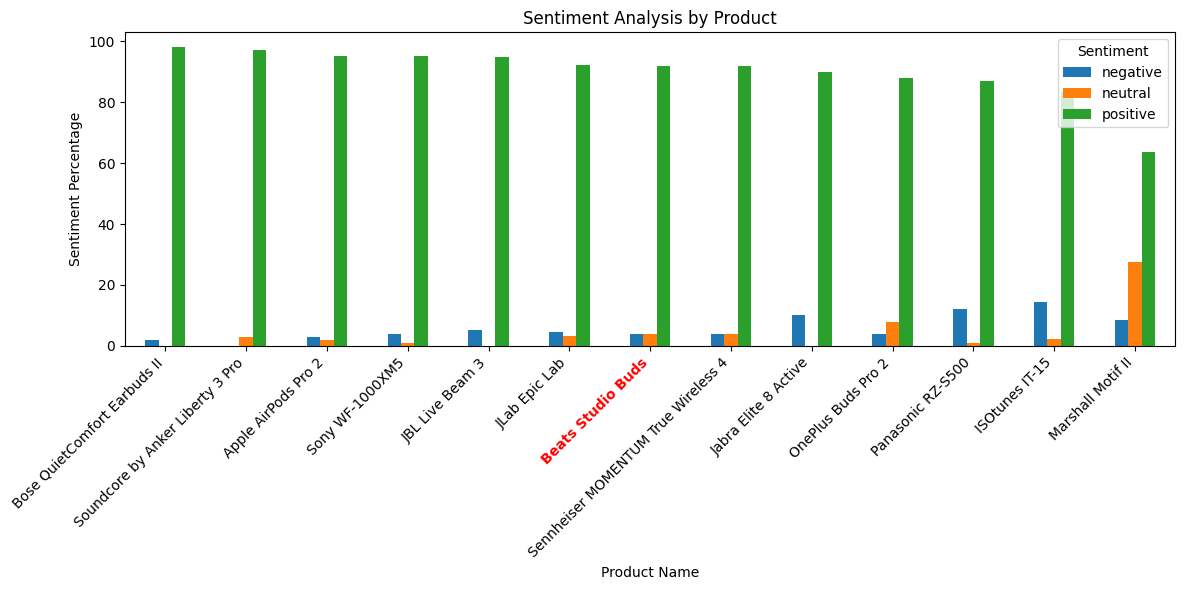

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by product name and calculate sentiment percentages
sentiment_by_product = df.groupby('product_name')['sentiment'].value_counts(normalize=True).unstack() * 100

# Sort by positive sentiment in descending order
sentiment_by_product = sentiment_by_product.sort_values(by='positive', ascending=False)

# Create a bar chart
sentiment_by_product.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Product Name')
plt.ylabel('Sentiment Percentage')
plt.title('Sentiment Analysis by Product')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()

xticks = plt.gca().get_xticks()
beats_index = sentiment_by_product.index.get_loc('Beats Studio Buds')

plt.gca().get_xticklabels()[beats_index].set_color('red')
plt.gca().get_xticklabels()[beats_index].set_weight('bold')

plt.show()

The bar graph above shows the sentiment analysis of the products and Beats Studio Buds is average regarding positive sentiment with little negative and neutral sentiment. Also, it has about the same amount of negative reviews as the Apple Airpods Pro 2, and nearly the same positive sentiment as Jlab Epic Lab product.

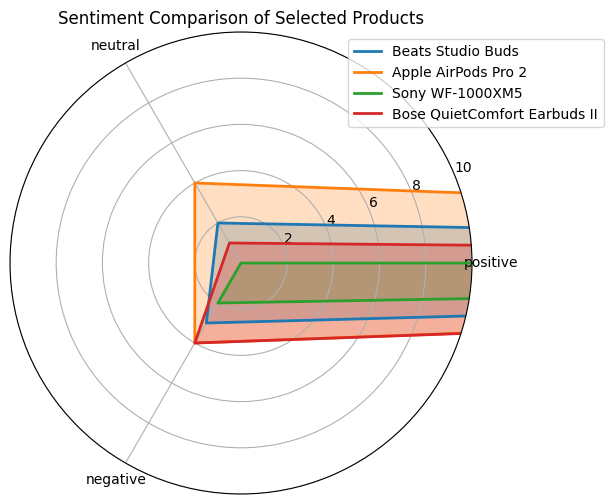

In [ ]:
from math import pi
import matplotlib.pyplot as plt
import pandas as pd

# Radar chart setup
labels = ['positive', 'neutral', 'negative']
products = ['Beats Studio Buds', 'Apple AirPods Pro 2', 'Sony WF-1000XM5', 'Bose QuietComfort Earbuds II']

# Extract data for selected products
df_radar = df[df['product_name'].isin(products)]
df_radar = df_radar.groupby('product_name')['sentiment'].value_counts(normalize=True).unstack().fillna(0) * 100
df_radar = df_radar[['positive', 'neutral', 'negative']]  # Reorder columns
stats = df_radar.values

# Set up the radar chart
angles = [n / float(len(labels)) * 2 * pi for n in range(len(labels))]
angles += angles[:1]  # Complete the circle

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': 'polar'})

# Plot data for each product
for i, product in enumerate(products):
    values = stats[i].tolist() + stats[i].tolist()[:1]  # Close the circle
    ax.plot(angles, values, linewidth=2, label=product)
    ax.fill(angles, values, alpha=0.25)

# Add labels and legend
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title('Sentiment Comparison of Selected Products')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

# Zoom in by setting y-axis limits
ax.set_ylim(0, 10)  # Adjust the upper limit as needed

plt.show()

In the radar chart above, it shows a sentiment comparison of Beats, Apple, Sony and Bose products. The Beats Studio Buds shows a stronger positve correlation compared to Apple Air Pods as Apple is has more neutral sentiment than all these 5 products, and Bose QuitComfort Earbuds has more negative reviews than the other products.

### 8.3 SWOT Analysis


###SWOT Analysis for Beats by Dre

**Strengths**

1. *High Positive Sentiment*: With 92% positive feedback, Beats Studio Buds show strong consumer satisfaction, suggesting effective branding and product performance.
2. *Brand Reputation*: Beats benefits from association with Apple’s ecosystem and a focus on lifestyle and fashion, making the product appealing to a wider, non-technical audience.
3. *Competitive Sound Quality*: Positive sentiments align with customer expectations regarding sound performance, a core factor in comparison with other premium brands like Bose and Sony.
4. *Design and Comfort*: Beats’ emphasis on aesthetic design and comfort gives it a unique edge, attracting both casual users and fitness enthusiasts.

**Weaknesses**

1. Limited Differentiation: Compared to competitors like Bose and Sony, which excel in noise-canceling features, Beats products may not be perceived as the best in class for audio fidelity or tech innovation.
2. *Moderate Neutral and Negative Sentiments*: The 4% neutral and 4% negative feedback indicates some customers are not fully satisfied, possibly hinting at issues with battery life, connectivity, or pricing.
3. *Price Sensitivity*: Beats products are often viewed as premium-priced, which could deter cost-conscious customers looking at alternatives from brands like JLab or OnePlus.

**Opportunities**

1. *Expanding Product Features*: Adding advanced features such as customizable EQ or longer battery life could boost satisfaction and help the brand compete with leaders like Sony and Bose.
2. *Growing Market for Wireless Earbuds*: As more consumers adopt wireless audio solutions for work-from-home and fitness, Beats has an opportunity to expand its market share.
3. *Leveraging Apple’s Ecosystem*: Further integration with Apple's software ecosystem (e.g., seamless switching across devices) can enhance user experience and increase retention.
4. *Sustainability Initiatives*: Introducing eco-friendly packaging or sustainability practices can help align the brand with evolving consumer values.

**Threats**

1. *Intense Competition*: Brands like Sony, Bose, and Apple offer strong competition with highly rated products that outperform Beats in technical areas (e.g., noise-cancelation, battery life).
2. *New Market Entrants*: Companies like Soundcore by Anker and OnePlus provide affordable alternatives with decent performance, threatening Beats' position among price-sensitive consumers.
3. Negative Sentiment Risk: If product issues (e.g., connectivity, durability) aren't resolved, negative feedback could increase, harming brand perception.
4. *Market Saturation*: The earbuds market is becoming saturated, making it difficult to stand out unless new, innovative features are introduced.

This SWOT analysis shows that Beats by Dre is well-positioned with strong consumer sentiment and branding, but it must address product innovation, competitive differentiation, and price concerns to maintain and grow its market share.

## 9. Strategic Recommendations

### 9.1 Product Improvements


####1. Improve Sound Quality and Noise Cancelation
* Enhance noise-cancelation technology to compete with Bose QuietComfort Earbuds II and Sony WF-1000XM5.
* Introduce customizable EQ settings through the app, giving users more control over sound profiles to match individual preferences.

####2. Increase Battery Life and Charging Efficiency
* Extend battery life to align with competitors like the Sony WF-1000XM5 and Jabra Elite 8 Active, especially for power users.
* Optimize the charging case to offer faster charging or wireless charging capabilities.

####3. Address Connectivity Issues
* Improve Bluetooth stability and multi-device switching to avoid the frustration noted in negative feedback.
* Develop firmware updates to resolve potential bugs quickly and ensure smoother performance within the Apple ecosystem.

####4. Introduce New, Affordable Variants
* Launch a budget-friendly version of the Beats Studio Buds to appeal to price-sensitive consumers who are drawn to alternatives like ISOtunes and JLab products.
* Differentiate these lower-cost models with core features (e.g., good sound quality, decent battery life) while leaving premium features for higher-tier models.

####5. Expand Fitness-Oriented Features
* Introduce sweat resistance ratings or enhanced durability features, like Jabra Elite 8 Active, to appeal to fitness enthusiasts.
* Develop in-app fitness tracking integration (e.g., heart rate monitoring or guided workouts) to stand out in the fitness segment.

####6. Strengthen Integration within Apple Ecosystem
* Refine the seamless switching feature between Apple devices to create a frictionless experience.
* Add Find My integration for easy tracking of lost earbuds, similar to the Apple AirPods Pro 2.

####7. Focus on Sustainability and Packaging Innovation
* Use recyclable materials for packaging to align with consumer preferences for sustainability.
* Offer repair programs or trade-in options to extend the product lifecycle and attract eco-conscious consumers.

####8. Improve Customer Support and Firmware Updates
* Ensure proactive customer service with fast response times to address issues raised in negative feedback.
* Provide regular firmware updates to enhance product performance, responding to evolving customer needs.

These improvements would help Beats by Dre maintain competitive parity, meet evolving consumer expectations, and carve a stronger niche in the increasingly saturated wireless earbuds market.

### 9.2 Marketing Strategies


Here are recommendations for marketing strategies to enhance consumer perception and satisfaction for Beats by Dre:

####1. Leverage Influencer Marketing and Brand Ambassadors
* Collaborate with fitness influencers, musicians, and athletes to showcase product versatility (e.g., workouts, concerts, and lifestyle use).
* Partner with celebrity ambassadors known for style and innovation to reinforce the brand’s premium image, similar to previous collaborations with artists like Dr. Dre and LeBron James.

####2. Launch Limited-Edition and Customizable Products
* Introduce limited-edition colors or artist collaborations to appeal to brand-conscious consumers.
* Offer personalization options (e.g., engraving or unique case designs) to attract customers who value individuality.

####3. Promote Cross-Compatibility with Apple Ecosystem
* Highlight the Apple ecosystem integration in marketing campaigns to attract iPhone and Apple Watch users.
* Offer bundle promotions with Apple devices, like discounts when purchasing Beats with MacBooks or iPads.

####4. Create Targeted Campaigns for Fitness Enthusiasts
* Market fitness features (e.g., water resistance and secure fit) through partnerships with fitness apps or gym chains.
* Launch fitness challenges or campaigns tied to the product, encouraging consumers to use Beats Studio Buds during workouts and share their progress on social media.

####5. Enhance Sustainability Messaging
* Emphasize any sustainable packaging or eco-friendly practices to attract environmentally conscious consumers.
* Promote recycling programs or trade-in initiatives to create a positive brand image around sustainability.

####6. Utilize Social Proof and User-Generated Content
* Encourage customers to share their experiences on social media with hashtags (e.g., #MyBeatsExperience) and highlight positive reviews in campaigns.
* Feature user-generated content (UGC) across platforms to build trust and authenticity with new consumers.

####7. Offer Loyalty Programs and Referral Incentives
* Introduce a loyalty program where repeat customers can earn points for discounts or exclusive merchandise.
* Provide referral incentives (e.g., discounts for both referrers and new buyers) to increase brand advocacy and expand the customer base.

####8. Run Comparison-Based Campaigns Highlighting Strengths
* Create comparison ads showing Beats Studio Buds against competitors (e.g., Bose or Sony), focusing on superior design, sound, and affordability.
* Promote the Beats Studio Buds’ strengths in areas where competitors lag, such as style, portability, or Apple device integration.

####9. Focus on After-Sales Customer Engagement
* Send personalized thank-you messages after purchase and offer helpful tips on using Beats products.
* Introduce free firmware updates or add-on features as part of ongoing engagement, creating a sense of continuous value.

####10. Invest in Experiential Marketing Campaigns
* Host pop-up stores or listening events where customers can experience the product firsthand.
*Collaborate with music festivals or sports events to create immersive experiences featuring Beats products.

These strategies will not only strengthen consumer trust and satisfaction but also position Beats by Dre as a trendy, high-quality, and versatile brand in the competitive audio market.





### 9.3 Future Research


###Areas for Future Research or Additional Data Collection

####1. Deeper Sentiment Analysis with Advanced NLP Techniques
* Use topic modeling (e.g., LDA) to identify specific themes in customer reviews (e.g., comfort, battery life, or sound quality).
* Analyze emotion-based sentiment (joy, frustration, satisfaction) to uncover more nuanced insights.

####2. Competitor Analysis on Pricing and Promotions
* Collect data on seasonal discounts, promotional campaigns, and bundle offers by competitors to assess their impact on consumer perception and sales.
* Explore price elasticity to understand how different pricing strategies impact demand for Beats products.

####3. Survey and Focus Group Data for Qualitative Insights
* Conduct customer surveys to gather insights about expectations, satisfaction, and brand loyalty.
* Use focus groups to explore product experiences in more depth, providing qualitative insights that complement review data.

####4. Geographic and Demographic Data Segmentation
* Collect region-specific data to identify how consumer preferences vary across different markets (e.g., North America vs. Europe).
* Analyze demographic trends such as age, gender, and income to target marketing campaigns more effectively.

####5. Social Media Sentiment and Engagement Metrics
* Perform sentiment analysis on social media platforms (Twitter, Instagram) to understand brand perception in real time.
* Track engagement metrics (likes, shares, and comments) to measure the success of marketing campaigns.

####6. Product Usage and Feature Preference Data
* Gather data on how customers use specific features (e.g., noise cancellation, transparency mode) and battery performance over time.
* Conduct research on post-purchase behavior to determine how often customers engage with firmware updates or product upgrades.

####7. Market Trend Analysis for Emerging Technologies
* Research emerging trends, such as spatial audio, AI-powered enhancements, and sustainability efforts in consumer electronics.
* Monitor innovations by competitors to identify areas where Beats can gain a competitive edge.

####8. Customer Retention and Loyalty Metrics
* Collect repeat purchase and subscription data to evaluate brand loyalty and customer retention.
* Track Net Promoter Score (NPS) to assess customer satisfaction and willingness to recommend the product.

####9. Correlation between Ratings and Sales Performance
* Analyze the relationship between review sentiment and sales performance to identify how positive or negative feedback impacts revenue.
* Compare sales trends across competitors to identify areas where Beats can improve or gain market share.

####10. Supply Chain and Production Efficiency Data
* Investigate how supply chain disruptions affect product availability and customer satisfaction.
* Collect data on production costs to assess potential areas for cost optimization without compromising quality.

These areas for future research will enhance the depth and accuracy of the analysis, enabling Beats by Dre to refine its product offerings, marketing strategies, and customer engagement efforts more effectively.

## 10. Conclusion

###Key Findings and Their Implications

####1. Positive Sentiment Dominates
* Beats Studio Buds received 92% positive reviews, reflecting strong consumer satisfaction with the product’s design, sound quality, and overall performance.
* However, 4% neutral and 4% negative sentiment highlight areas for improvement, particularly in noise cancellation and battery life.

####2. Competitor Comparison Highlights Strengths and Weaknesses
* Beats outperforms several competitors, such as ISOtunes IT-15 and Marshall Motif II, but still trails behind Bose QuietComfort Earbuds II and Sony WF-1000XM5 in specific areas like noise cancellation and premium audio experience.
* Apple AirPods Pro 2 and Sony WF-1000XM5 set high benchmarks in consumer expectations, especially in feature innovation and user experience.

####3. Market Positioning and Brand Loyalty
* The analysis suggests that Beats benefits from brand recognition and aesthetics but must address specific performance gaps to remain competitive.
* Minor issues (e.g., comfort or fit concerns) indicate opportunities to enhance product usability and maintain consumer trust.

####4. Opportunities for Marketing and Innovation
* There is potential for refined messaging in marketing campaigns, emphasizing sound quality, design, and lifestyle fit.
* Feedback on battery life and customization options points toward avenues for product development and differentiation.

##Reflection on the Overall Project
This project provides valuable insights into consumer sentiment for Beats by Dre by using Amazon reviews as a data source to analyze customer experiences and satisfaction. The comparative analysis reveals how Beats stands in relation to key competitors, highlighting both its strengths (brand appeal and sound quality) and areas for improvement (battery life and feature innovation).

The sentiment analysis offers actionable insights, demonstrating that while the overall perception is positive, addressing negative feedback can further enhance customer satisfaction. Integrating data from multiple products and platforms helped form a holistic view of the competitive landscape and gave Beats a clearer picture of market trends and consumer priorities.

This project also contributes to a deeper understanding of how sentiment analysis can inform business strategies, including product development and marketing. It underscores the importance of continuous monitoring of consumer feedback and aligning innovations with evolving customer needs to sustain brand relevance in a highly competitive market.

Going forward, the project opens avenues for future research on pricing strategies, social media sentiment, and region-specific trends, helping Beats refine its strategies to meet diverse consumer expectations and enhance brand loyalty.

## 11. References


###Sources
1.Amazon Reviews
* Customer feedback and reviews for Beats Studio Buds and competitor products sourced from Amazon.
2.Gemini AI
* Utilized for generating insights and analysis on sentiment from the collected data.
3.YouTube Videos
* Educational content and tutorials provided with the assignment tasks that guided the sentiment analysis and project methodologies.

###Tools
1.Oxylab
* A web scraper used to collect Amazon reviews and gather data for analysis.
2.Python Libraries
* Pandas: For data manipulation and analysis.
* Matplotlib/Seaborn: For data visualization and plotting sentiment analysis results.
* NLTK/TextBlob: For sentiment analysis of the collected reviews.
3.Google Colab
* Platform used for coding and executing the analysis.

###Extern Training Content
1.Consumer Insights Data Analytics Externship
* Training materials and resources from the externship program with Beats by Dre that informed methodologies and analytical frameworks applied in the project.

###Others
1.Competitor Product Reviews
* Customer reviews for competing products such as Apple AirPods Pro 2, Bose QuietComfort Earbuds II, Sony WF-1000XM5, etc., collected from various platforms (including Amazon).